# Statistical Analysis 

In [1]:
import pandas as pd 
import math
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

This line imports utils:

In [2]:
%run ../../utils/utils.py

## 1. Load Data

In [3]:
df = pd.read_csv("../../data/preprocessed.csv")
df = data_featuring_sensitivity(df)
df.head()

,s1_edad,s1_genero,s1_experiencia_clinica,s1_educacion,s1_titulo_terciario,s1_titulo,s1_no_titulo_universitario,s1_horas_semana_pacientes_atendidos,s1_contexto_trabajo,s1_orientacion_teo,...,s4_no_tiempo_aprender_tbe,s4_capacitacion_tbe_demasiado_dinero,s4_no_saber_tbe,s4_entrenamiento_clinico_no_info_tbe,s4_alianza_terapeutica_mas_importante,s4_terapias_igualmente_efectivas,s4_empleador_no_fondos_capacitacion_tbe,s4_exp_clinica_mas_importante_que_evidencia_cientifica,provincia_residencia,consentimiento_informado
0,41.0,Femenino,1.2,Licenciatura de Grado,NaN,Lic. en Psicología,NaN,12.0,Ámbito Privado,Ecléctico (más de una de estas opciones),...,4.0,4.0,7.0,NaN,6.0,4.0,6.0,2.0,Provincia de Buenos Aires,NaN
1,26.0,Femenino,0.2,Licenciatura de Grado,NaN,Lic. en Psicología,NaN,13.0,"Ámbito Privado, Obra Social o Prepaga",Terapias Cognitivas/Comportamentales,...,1.0,6.0,1.0,NaN,4.0,2.0,7.0,3.0,Provincia de Buenos Aires,NaN
2,27.0,Femenino,1.0,Carrera de Especialización,NaN,Lic. en Psicología,NaN,30.0,"Ámbito Privado, Obra Social o Prepaga",Terapias Cognitivas/Comportamentales,...,1.0,4.0,1.0,1.0,1.0,1.0,NaN,4.0,Ciudad Autónoma de Buenos Aires (CABA),NaN
3,30.0,Masculino,1.3,Carrera de Especialización,NaN,Lic. en Psicología,NaN,35.0,Ámbito Privado,Terapias Cognitivas/Comportamentales,...,2.0,3.0,NaN,4.0,3.0,NaN,7.0,3.0,Provincia de Buenos Aires,NaN
4,26.0,Masculino,2.0,Licenciatura de Grado,NaN,Lic. en Psicología,NaN,46.0,Ámbito Público (hospital u otro),Terapias Cognitivas/Comportamentales,...,4.0,6.0,1.0,4.0,4.0,1.0,7.0,4.0,Provincia de Buenos Aires,NaN


## Statistical Assumptions for ANCOVA

In [18]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
import warnings
warnings.filterwarnings('ignore')

subset_orientations = [
    'Ecléctico (más de una de estas opciones)',
    'Terapias Cognitivas/Comportamentales',
    'Psicoanálisis',
    'Sistémica'
]

covariates = ['s1_edad', 's1_genero', 's1_horas_semana_pacientes_atendidos']

def check_parallel_slopes(df, variables, section_name, exclude_zeros=True, alpha=0.05):
    """
    Checks only the homogeneity of regression slopes assumption (the critical
    ANCOVA-specific assumption). For each variable, fits a model with
    orientation × covariate interaction terms. A significant interaction
    (p < .05) means the covariate relates differently to the DV across
    orientation groups — invalidating the standard ANCOVA adjustment.

    All other assumptions (normality, homoscedasticity) are noted as
    robustness concerns but do not invalidate the analysis given adequate N.
    """

    print(f"\n{'█'*90}")
    print(f"  PARALLEL SLOPES CHECK — {section_name}")
    print(f"  Critical assumption: orientation × covariate interaction must be ns")
    print(f"{'█'*90}\n")

    results = []

    other_covs = {
        's1_edad':                             's1_genero + s1_horas_semana_pacientes_atendidos',
        's1_genero':                           's1_edad + s1_horas_semana_pacientes_atendidos',
        's1_horas_semana_pacientes_atendidos': 's1_edad + s1_genero'
    }

    print(f"{'Variable':<52} {'edad_p':>8} {'genero_p':>10} {'horas_p':>8} {'status':>12}")
    print("-" * 95)

    for v in variables:
        cols_needed = ['s1_orientacion_teo', v] + covariates
        subset = df[cols_needed].copy()
        subset = subset[subset['s1_orientacion_teo'].isin(subset_orientations)]

        if exclude_zeros:
            subset = subset[subset[v] != 0]

        subset = subset.dropna()

        # Encode gender as numeric
        subset['s1_genero'] = pd.Categorical(subset['s1_genero']).codes

        if len(subset) < 20:
            print(f"{v:<52} {'—':>8} {'—':>10} {'—':>8} {'N too small':>12}")
            continue

        p_vals = {}
        failed = False

        for cov in covariates:
            try:
                rest = other_covs[cov]
                formula = f"{v} ~ C(s1_orientacion_teo) * {cov} + {rest}"
                model   = smf.ols(formula, data=subset).fit()
                aov     = anova_lm(model, typ=2)
                int_row = f"C(s1_orientacion_teo):{cov}"
                if int_row in aov.index:
                    p_vals[cov] = aov.loc[int_row, 'PR(>F)']
                else:
                    p_vals[cov] = np.nan
            except Exception:
                p_vals[cov] = np.nan
                failed = True

        # Flag if any interaction is significant
        violations = [cov for cov, p in p_vals.items()
                      if not np.isnan(p) and p < alpha]

        if violations:
            status = "⚠ VIOLATED"
        elif failed:
            status = "? error"
        else:
            status = "✓ ok"

        p_edad   = p_vals.get('s1_edad', np.nan)
        p_genero = p_vals.get('s1_genero', np.nan)
        p_horas  = p_vals.get('s1_horas_semana_pacientes_atendidos', np.nan)

        def fmt_p(p):
            if np.isnan(p): return '    —'
            marker = '*' if p < alpha else ' '
            return f"{p:.3f}{marker}"

        print(f"{v:<52} {fmt_p(p_edad):>8} {fmt_p(p_genero):>10} "
              f"{fmt_p(p_horas):>8} {status:>12}")

        results.append({
            'variable':      v,
            'p_edad':        p_edad,
            'p_genero':      p_genero,
            'p_horas':       p_horas,
            'violated':      len(violations) > 0,
            'violated_covs': violations
        })

    # ── Summary ───────────────────────────────────────────────────────────────
    violated = [r for r in results if r['violated']]
    ok       = [r for r in results if not r['violated']]

    print(f"\n  ✓ Assumption met:    {len(ok)}/{len(results)} variables")
    print(f"  ⚠ Assumption violated: {len(violated)}/{len(results)} variables")

    if violated:
        print(f"\n  Violated variables (interpret ANCOVA results with caution):")
        for r in violated:
            covs = ', '.join(r['violated_covs'])
            print(f"    • {r['variable']} — interaction with: {covs}")

    return pd.DataFrame(results)


# ── Run for all three sections ─────────────────────────────────────────────────

slopes_s2 = check_parallel_slopes(
    df, variables_s2,
    'Section 2 — Factors influencing theoretical orientation',
    exclude_zeros=False
)

slopes_s3 = check_parallel_slopes(
    df, variables_s3,
    'Section 3 — Sources used to improve clinical skills',
    exclude_zeros=False
)

slopes_s4 = check_parallel_slopes(
    df, variables_s4,
    'Section 4 — Research attitudes',
    exclude_zeros=True
)


██████████████████████████████████████████████████████████████████████████████████████████
  PARALLEL SLOPES CHECK — Section 2 — Factors influencing theoretical orientation
  Critical assumption: orientation × covariate interaction must be ns
██████████████████████████████████████████████████████████████████████████████████████████

Variable                                               edad_p   genero_p  horas_p       status
-----------------------------------------------------------------------------------------------
s2_evidencia_cientifica                                0.009*     0.286    0.879    ⚠ VIOLATED
s2_experiencia_personal                                0.925      0.554    0.923          ✓ ok
s2_entrenamiento_clinica                               0.808      0.189    0.909          ✓ ok
s2_tratamiento_preferencia_consultantes                0.051      0.789    0.561          ✓ ok
s2_intuicion                                           0.369      0.811    0.487          ✓ o

---
## Zero and Eight Check — Preprocessing Verification

Verifies that zero-handling was applied correctly in both preprocessed datasets before running analyses.

| Dataset | Zeros in S3/S4 | Purpose |
|---|---|---|
| `sensitivity_featured_data.csv` | Recoded to `NaN` | Primary ANCOVA analysis |
| `featured_data.csv` | Retained as valid | Cluster analysis |

**Expected output:**
- `sensitivity_featured_data.csv` → zeros = 0, eights = 0 everywhere. Any `⚠` flag indicates a preprocessing error.
- `featured_data.csv` → zeros present in S3/S4 (retained as valid), eights = 0 everywhere (`8 → 0` recode already applied in `data_featuring()`).

In [ ]:
df_sensitivity = pd.read_csv('../../data/sensitivity_featured_data.csv')
df_featured    = pd.read_csv('../../data/featured_data.csv')

all_vars = variables_s2 + variables_s3 + variables_s4

print("=" * 70)
print("  ZERO AND EIGHT CHECK — sensitivity_featured_data.csv")
print("=" * 70)
print(f"\n{'Variable':<52} {'zeros':>6} {'eights':>7} {'NaNs':>6}")
print("-" * 70)
for v in all_vars:
    if v in df_sensitivity.columns:
        zeros  = (df_sensitivity[v] == 0).sum()
        eights = (df_sensitivity[v] == 8).sum()
        nans   = df_sensitivity[v].isna().sum()
        flag   = "  ⚠" if zeros > 0 or eights > 0 else ""
        print(f"{v:<52} {zeros:>6} {eights:>7} {nans:>6}{flag}")

print("\n" + "=" * 70)
print("  ZERO AND EIGHT CHECK — featured_data.csv")
print("=" * 70)
print(f"\n{'Variable':<52} {'zeros':>6} {'eights':>7} {'NaNs':>6}")
print("-" * 70)
for v in all_vars:
    if v in df_featured.columns:
        zeros  = (df_featured[v] == 0).sum()
        eights = (df_featured[v] == 8).sum()
        nans   = df_featured[v].isna().sum()
        flag   = "  ⚠" if zeros > 0 or eights > 0 else ""
        print(f"{v:<52} {zeros:>6} {eights:>7} {nans:>6}{flag}")

  ZERO AND EIGHT CHECK — sensitivity_featured_data.csv

Variable                                              zeros  eights   NaNs
----------------------------------------------------------------------
s2_evidencia_cientifica                                   0       0      6
s2_experiencia_personal                                   0       0     10
s2_entrenamiento_clinica                                  0       0     10
s2_tratamiento_preferencia_consultantes                   0       0     31
s2_intuicion                                              0       0     51
s2_terapia_personal                                       0       0     24
s3_tratamiento_personal_consultantes                      0       0      1
s3_investigacion_empirica_ensayos_controlados             0       0     32
s3_supervision                                            0       0      4
s3_estudios_de_caso                                       0       0     22
s3_discusion_pares                              

---
## ANCOVA with FDR Correction

### Overview
This cell runs the primary inferential analysis for Sections 2, 3, and 4 of the survey.
It implements a **variable-by-variable one-way ANCOVA** approach with
**Benjamini-Hochberg False Discovery Rate (FDR) correction**, followed by
**Tukey HSD post-hoc tests** for all variables surviving correction.

Covariates controlled for in each ANCOVA: **age**, **gender**, and **weekly working hours**.

---

### Why variable-by-variable ANCOVA instead of MANCOVA?

The original analytical plan used MANCOVA. However, listwise deletion across all
Section 4 items simultaneously reduced the usable sample from N=261 to N=44 (83.1% loss),
because the 'No sabe/No contesta' (0) response category was unevenly distributed across
items and concentrated among psychoanalytic practitioners. Running MANCOVA on N=44 would
introduce severe selection bias, as the surviving sample would not be representative of
the original population.

The variable-by-variable ANCOVA approach solves this by applying **item-wise deletion**:
each variable uses its own maximum available N after removing non-responses, preserving
between 46% and 99% of the sample per item (N = 121–261).

---

### How zeros are handled

Before this cell runs, `data_featuring_sensitivity(df)` has already been applied to the
data (see the previous cell). That function performs three preprocessing steps:

1. **Section 2:** Response category 0 ('No sabe/No contesta') → `NaN`
2. **Section 4 subset:** Response category 8 ('No aplica — no considero que haya UN tipo
   de método científico') → 0 (must occur before step 3)
3. **Sections 3 AND 4:** All remaining 0s → `NaN`

As a result, by the time the ANCOVA runs, **there are no zeros left in the data** — all
non-responses are already encoded as `NaN`. The `exclude_zeros=True` flag for Section 4
is therefore redundant but retained as a safety net. All three sections treat
non-responses as missing data, handled via item-wise `dropna()`.

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.stats.multicomp as mc
import statsmodels.stats.multitest as smt
from statsmodels.stats.anova import anova_lma

df = pd.read_csv('../../data/sensitivity_featured_data.csv')

variables_s2 = [
    's2_evidencia_cientifica', 's2_experiencia_personal',
    's2_entrenamiento_clinica', 's2_tratamiento_preferencia_consultantes',
    's2_intuicion', 's2_terapia_personal'
]

variables_s3 = [
    's3_tratamiento_personal_consultantes',
    's3_investigacion_empirica_ensayos_controlados',
    's3_supervision', 's3_estudios_de_caso', 's3_discusion_pares',
    's3_libros', 's3_observaciones_casos_clinicos',
    's3_medidas_resultado', 's3_guias_manuales_clinicos'
]

variables_s4 = [
    's4_apertura_terapias_desarrolladas_por_investigadores',
    's4_nueva_terapia_intento',
    's4_terapia_manualizada', 's4_diagnosticos_utilizados_son_simples',
    's4_tratamientos_preferencia_no_probados_ensayo_controlado',
    's4_enfoque_tratamiento_individual',
    's4_alianza_terapeutica_mas_importante',
    's4_terapias_igualmente_efectivas',
    's4_exp_clinica_mas_importante_que_evidencia_cientifica',
    's4_actualizacion_info_cientifica',
    's4_formacion_enfasis_investigacion',
    's4_supervisores_terapia_evidencia_requerimiento',
    's4_atraer_consultantes_con_tbe',
    's4_hallazgos_cientificos_practica_diaria',
    's4_interes_aprender_tbe',
    's4_tratamientos_utilizados_base_empirica',
    's4_complejidad_consultantes_ensayos_clinicos',
    's4_consultantes_prefieren_otros_tratamientos',
    's4_no_tiempo_aprender_tbe',
    's4_capacitacion_tbe_demasiado_dinero',
    's4_no_saber_tbe',
    's4_entrenamiento_clinico_no_info_tbe',
    's4_empleador_no_fondos_capacitacion_tbe'
]

covariates = ['s1_edad', 's1_genero', 's1_horas_semana_pacientes_atendidos']

subset_orientations = [
    'Ecléctico (más de una de estas opciones)',
    'Terapias Cognitivas/Comportamentales',
    'Psicoanálisis',
    'Sistémica'
]

def run_ancova_per_variable(df, variables, section_name, exclude_zeros=True, alpha=0.05):
    """
    Runs one-way ANCOVA per variable with FDR correction.
    Covariates: age (s1_edad), gender (s1_genero), weekly hours (s1_horas_semana_pacientes_atendidos).
    Followed by Tukey HSD on the orientation factor for significant variables.

    Parameters:
    -----------
    df           : DataFrame with s1_orientacion_teo and covariate columns
    variables    : list of dependent variable names
    section_name : string label for printing
    exclude_zeros: if True, removes remaining 0s before analysis (treats as missing)
    alpha        : significance threshold
    """

    print(f"\n{'='*105}")
    print(f"  ANCOVA & FDR CORRECTION — {section_name} "
          f"({'zeros excluded' if exclude_zeros else 'zeros included'})")
    print(f"  Covariates: age, gender, weekly hours")
    print(f"{'='*105}")

    raw_results = []

    for v in variables:
        cols_needed = ['s1_orientacion_teo', v] + covariates
        subset = df[cols_needed].copy()

        # Filter to 4 orientations
        subset = subset[subset['s1_orientacion_teo'].isin(subset_orientations)]

        # Exclude zeros if requested
        if exclude_zeros:
            subset = subset[subset[v] != 0]

        # Drop NaNs across DV + covariates
        subset = subset.dropna()
        total_n = len(subset)

        # Need at least 2 groups with 2+ observations each
        group_counts = subset.groupby('s1_orientacion_teo')[v].count()
        if (group_counts < 2).any() or len(group_counts) < 2:
            raw_results.append({
                'var': v, 'n': total_n,
                'f': np.nan, 'p_raw': np.nan, 'eta2': np.nan,
                'subset': subset
            })
            continue

        try:
            # Fit ANCOVA model: DV ~ orientation + covariates
            # Using C() to treat orientation as categorical
            formula = (f"{v} ~ C(s1_orientacion_teo) "
                       f"+ s1_edad + s1_genero + s1_horas_semana_pacientes_atendidos")
            model = smf.ols(formula, data=subset).fit()
            aov_table = anova_lm(model, typ=2)

            # Extract orientation F and p
            orient_row = aov_table.loc['C(s1_orientacion_teo)']
            f_val = orient_row['F']
            p_val = orient_row['PR(>F)']

            # Partial eta-squared for orientation factor
            ss_orient = orient_row['sum_sq']
            ss_resid  = aov_table.loc['Residual', 'sum_sq']
            eta2_partial = ss_orient / (ss_orient + ss_resid)

        except Exception as e:
            print(f"  ✗ ANCOVA failed for {v}: {e}")
            raw_results.append({
                'var': v, 'n': total_n,
                'f': np.nan, 'p_raw': np.nan, 'eta2': np.nan,
                'subset': subset
            })
            continue

        raw_results.append({
            'var': v, 'n': total_n,
            'f': f_val, 'p_raw': p_val, 'eta2': eta2_partial,
            'subset': subset
        })

    # FDR correction across valid results
    valid_results = [r for r in raw_results if not np.isnan(r['p_raw'])]
    p_values     = [r['p_raw'] for r in valid_results]
    reject, pvals_corrected, _, _ = smt.multipletests(
        p_values, alpha=alpha, method='fdr_bh'
    )

    # ── Summary table ─────────────────────────────────────────────────────────
    print(f"\n{'Variable':<52} {'N':>5} {'F':>8} {'Raw p':>8} "
          f"{'Adj p':>8} {'pη²':>6} {'sig':>5}")
    print("-" * 100)

    significant_vars = []

    for i, r in enumerate(valid_results):
        p_adj      = pvals_corrected[i]
        sig_marker = ("***" if p_adj < 0.001 else
                      "**"  if p_adj < 0.01  else
                      "*"   if p_adj < 0.05  else "")

        print(f"{r['var']:<52} {r['n']:>5} {r['f']:>8.3f} "
              f"{r['p_raw']:>8.4f} {p_adj:>8.4f} "
              f"{r['eta2']:>6.3f} {sig_marker:>5}")

        if reject[i]:
            significant_vars.append({**r, 'p_adj': p_adj})

    # ── Tukey HSD for significant variables ───────────────────────────────────
    # Note: Tukey runs on raw group means (unadjusted for covariates).
    # This is standard practice — it identifies which pairs differ,
    # but the means shown are not covariate-adjusted.
    if significant_vars:
        print(f"\n\n{'─'*105}")
        print(f"  TUKEY HSD — Significant variables (FDR adj p < {alpha})")
        print(f"  Note: means are unadjusted for covariates")
        print(f"{'─'*105}")

        for r in significant_vars:
            v      = r['var']
            subset = r['subset']
            print(f"\n► Post-hoc: {v}  [pη² = {r['eta2']:.3f}, adj p = {r['p_adj']:.4f}]")
            res    = mc.MultiComparison(subset[v], subset['s1_orientacion_teo'])
            print(res.tukeyhsd().summary())
    else:
        print(f"\n► No variable survived FDR correction at alpha={alpha}.")

    return raw_results, pvals_corrected


# ── Run for all three sections ─────────────────────────────────────────────────

results_ancova_s2 = run_ancova_per_variable(
    df, variables_s2,
    'Section 2 — Factors influencing theoretical orientation',
    exclude_zeros=False   # S2 zeros already NaN in df
)

results_ancova_s3 = run_ancova_per_variable(
    df, variables_s3,
    'Section 3 — Sources used to improve clinical skills',
    exclude_zeros=False   # S3 zeros already NaN in df
)

results_ancova_s4 = run_ancova_per_variable(
    df, variables_s4,
    'Section 4 — Research attitudes',
    exclude_zeros=True    # remove any remaining 0s
)


  ANCOVA & FDR CORRECTION — Section 2 — Factors influencing theoretical orientation (zeros included)
  Covariates: age, gender, weekly hours

Variable                                                 N        F    Raw p    Adj p    pη²   sig
----------------------------------------------------------------------------------------------------
s2_evidencia_cientifica                                256   46.065   0.0000   0.0000  0.359   ***
s2_experiencia_personal                                252    0.381   0.7667   0.9147  0.005      
s2_entrenamiento_clinica                               253    0.863   0.4611   0.7764  0.010      
s2_tratamiento_preferencia_consultantes                233    0.173   0.9147   0.9147  0.002      
s2_intuicion                                           213    0.760   0.5176   0.7764  0.011      
s2_terapia_personal                                    239    8.588   0.0000   0.0001  0.101   ***


─────────────────────────────────────────────────────────────

## ANCOVA Bonferroni Correction

In [24]:
# ── Bonferroni sensitivity check ──────────────────────────────────────────────
# Runs the same ANCOVA but with Bonferroni correction instead of FDR (BH).
# Purpose: confirm that primary findings are robust to a more conservative threshold.
# Only the significance counts are compared — F values and pη² are identical.

def run_ancova_bonferroni(df, variables, section_name, exclude_zeros=True, alpha=0.05):
    """Same as run_ancova_per_variable but uses Bonferroni correction."""

    raw_results = []

    for v in variables:
        cols_needed = ['s1_orientacion_teo', v] + covariates
        subset = df[cols_needed].copy()
        subset = subset[subset['s1_orientacion_teo'].isin(subset_orientations)]
        if exclude_zeros:
            subset = subset[subset[v] != 0]
        subset = subset.dropna()

        group_counts = subset.groupby('s1_orientacion_teo')[v].count()
        if (group_counts < 2).any() or len(group_counts) < 2:
            raw_results.append({'var': v, 'p_raw': np.nan})
            continue

        try:
            formula = (f"{v} ~ C(s1_orientacion_teo) "
                       f"+ s1_edad + s1_genero + s1_horas_semana_pacientes_atendidos")
            model     = smf.ols(formula, data=subset).fit()
            aov_table = anova_lm(model, typ=2)
            p_val     = aov_table.loc['C(s1_orientacion_teo)', 'PR(>F)']
        except:
            raw_results.append({'var': v, 'p_raw': np.nan})
            continue

        raw_results.append({'var': v, 'p_raw': p_val})

    valid   = [r for r in raw_results if not np.isnan(r['p_raw'])]
    p_vals  = [r['p_raw'] for r in valid]
    _, bonf_corrected, _, _ = smt.multipletests(p_vals, alpha=alpha, method='bonferroni')

    return {r['var']: p for r, p in zip(valid, bonf_corrected)}


# ── Run Bonferroni for all sections ───────────────────────────────────────────

bonf_s2 = run_ancova_bonferroni(df, variables_s2,
    'Section 2', exclude_zeros=False)
bonf_s3 = run_ancova_bonferroni(df, variables_s3,
    'Section 3', exclude_zeros=False)
bonf_s4 = run_ancova_bonferroni(df, variables_s4,
    'Section 4', exclude_zeros=True)

# ── Comparison table: FDR vs Bonferroni ───────────────────────────────────────

def compare_corrections(fdr_raw, fdr_corrected, bonf_corrected, variables, section_name, alpha=0.05):
    """
    Prints a side-by-side comparison of FDR and Bonferroni significance decisions.
    Flags variables where the two methods disagree.
    """
    valid_fdr = [r for r in fdr_raw if not np.isnan(r['p_raw'])]

    print(f"\n{'='*90}")
    print(f"  FDR vs BONFERRONI — {section_name}")
    print(f"{'='*90}")
    print(f"\n  {'Variable':<52} {'FDR adj p':>10} {'FDR sig':>8} {'Bonf adj p':>11} {'Bonf sig':>9} {'Match':>7}")
    print(f"  {'-'*88}")

    n_agree = 0
    n_disagree = 0

    for i, r in enumerate(valid_fdr):
        v          = r['var']
        fdr_p      = fdr_corrected[i]
        bonf_p     = bonf_corrected.get(v, np.nan)
        fdr_sig    = '✓' if fdr_p  < alpha else '—'
        bonf_sig   = '✓' if bonf_p < alpha else '—'
        match      = '✓' if fdr_sig == bonf_sig else '⚠ DIFF'
        if fdr_sig == bonf_sig:
            n_agree += 1
        else:
            n_disagree += 1
        print(f"  {v:<52} {fdr_p:>10.4f} {fdr_sig:>8} {bonf_p:>11.4f} {bonf_sig:>9} {match:>7}")

    print(f"\n  Agreement: {n_agree}/{n_agree+n_disagree} variables")
    print(f"  Disagreements: {n_disagree}/{n_agree+n_disagree} variables")


compare_corrections(results_ancova_s2[0], results_ancova_s2[1], bonf_s2, variables_s2,
    'Section 2 — Factors influencing theoretical orientation')

compare_corrections(results_ancova_s3[0], results_ancova_s3[1], bonf_s3, variables_s3,
    'Section 3 — Sources used to improve clinical skills')

compare_corrections(results_ancova_s4[0], results_ancova_s4[1], bonf_s4, variables_s4,
    'Section 4 — Research attitudes')


  FDR vs BONFERRONI — Section 2 — Factors influencing theoretical orientation

  Variable                                              FDR adj p  FDR sig  Bonf adj p  Bonf sig   Match
  ----------------------------------------------------------------------------------------
  s2_evidencia_cientifica                                  0.0000        ✓      0.0000         ✓       ✓
  s2_experiencia_personal                                  0.9147        —      1.0000         —       ✓
  s2_entrenamiento_clinica                                 0.7764        —      1.0000         —       ✓
  s2_tratamiento_preferencia_consultantes                  0.9147        —      1.0000         —       ✓
  s2_intuicion                                             0.7764        —      1.0000         —       ✓
  s2_terapia_personal                                      0.0001        ✓      0.0001         ✓       ✓

  Agreement: 6/6 variables
  Disagreements: 0/6 variables

  FDR vs BONFERRONI — Section 3 — 

## Plot ANCOVA Results

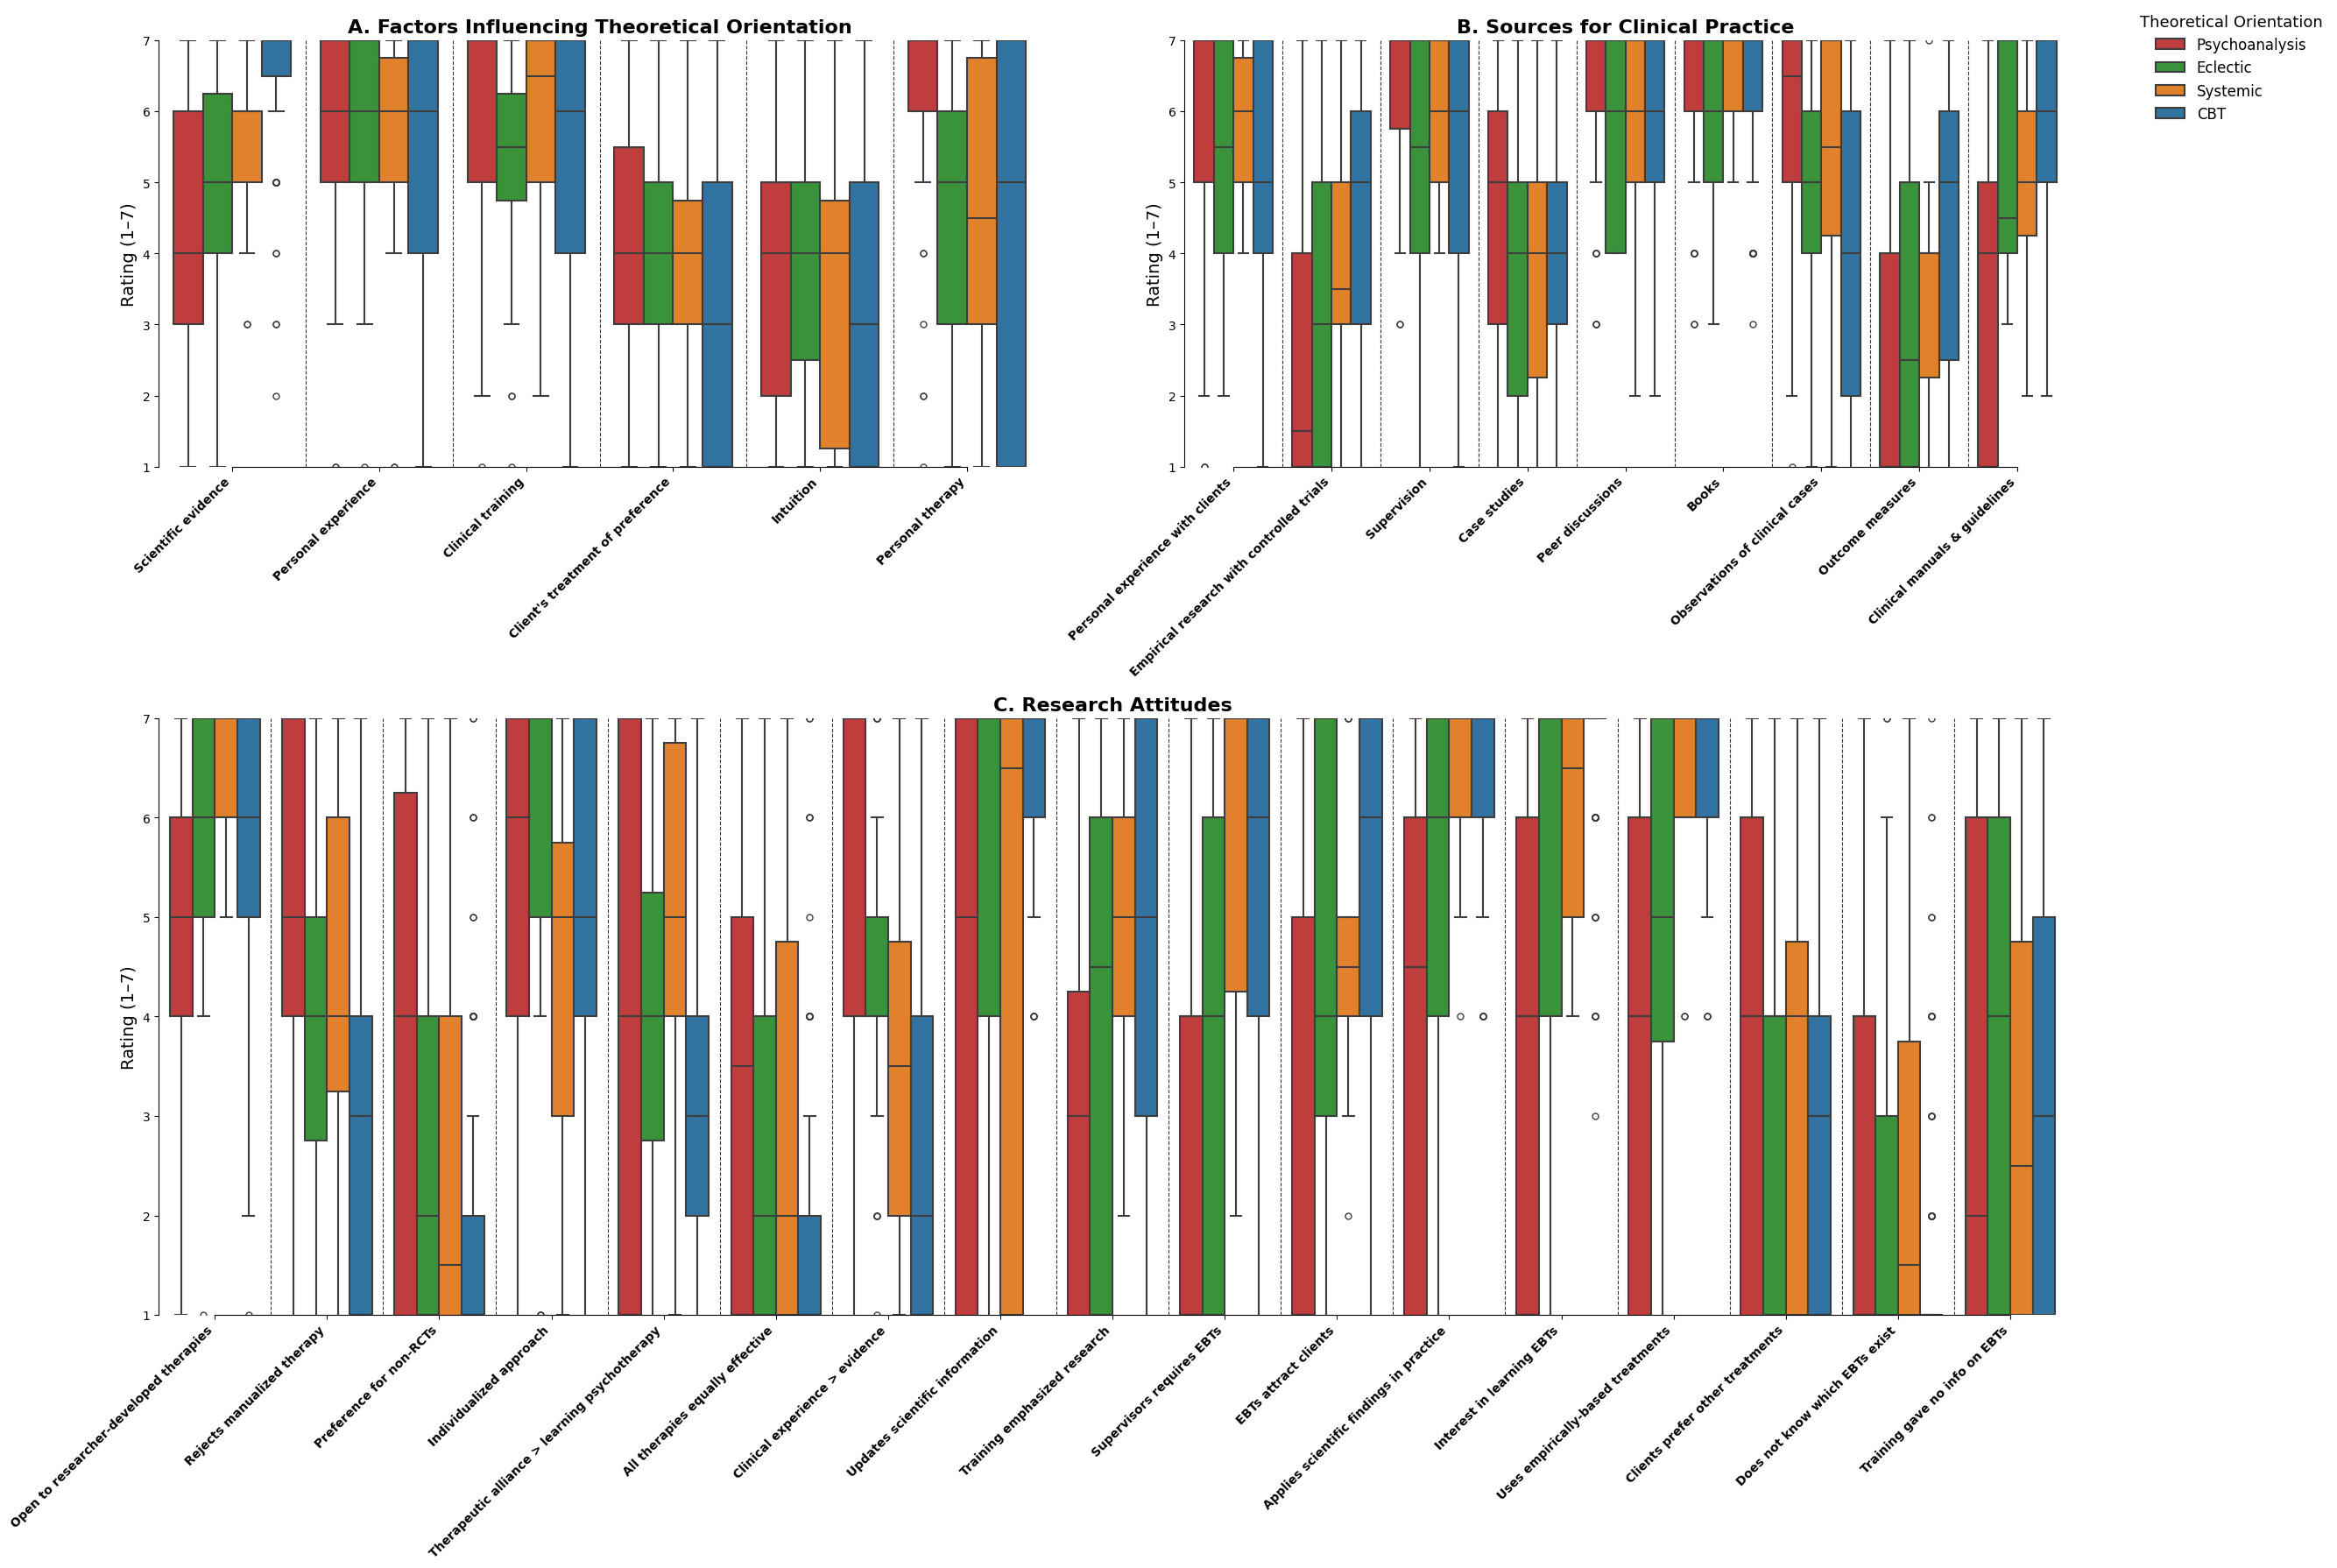

In [15]:
import matplotlib.pyplot as plt  
import seaborn as sns
import pandas as pd
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import matplotlib
import numpy as np

# ── Pretty labels ─────────────────────────────────────────────────────────────

pretty_labels_s2 = {
    's2_evidencia_cientifica': 'Scientific evidence',
    's2_experiencia_personal': 'Personal experience',
    's2_entrenamiento_clinica': 'Clinical training',
    's2_tratamiento_preferencia_consultantes': "Client's treatment of preference",
    's2_intuicion': 'Intuition',
    's2_terapia_personal': 'Personal therapy',
}

pretty_labels_s3 = {
    's3_tratamiento_personal_consultantes': "Personal experience with clients", 
    's3_investigacion_empirica_ensayos_controlados': 'Empirical research with controlled trials',
    's3_supervision': 'Supervision',
    's3_estudios_de_caso': 'Case studies',
    's3_discusion_pares': 'Peer discussions',
    's3_libros': 'Books',
    's3_observaciones_casos_clinicos': 'Observations of clinical cases',
    's3_medidas_resultado': 'Outcome measures',
    's3_guias_manuales_clinicos': 'Clinical manuals & guidelines',
}

pretty_labels_s4 = {
    's4_alianza_terapeutica_mas_importante': 'Therapeutic alliance > learning psychotherapy',
    's4_apertura_terapias_desarrolladas_por_investigadores': 'Open to researcher-developed therapies',
    's4_atraer_consultantes_con_tbe': 'EBTs attract clients', 
    's4_capacitacion_tbe_demasiado_dinero': 'EBT training is too expensive', 
    's4_complejidad_consultantes_ensayos_clinicos': 'Clients too complex for RCTs',
    's4_enfoque_tratamiento_individual': 'Individualized approach',  
    's4_exp_clinica_mas_importante_que_evidencia_cientifica': 'Clinical experience > evidence',  
    's4_hallazgos_cientificos_practica_diaria': 'Applies scientific findings in practice',  
    's4_interes_aprender_tbe': 'Interest in learning EBTs',  
    's4_supervisores_terapia_evidencia_requerimiento': 'Supervisors requires EBTs',  
    's4_terapia_manualizada': 'Rejects manualized therapy',  
    's4_terapias_igualmente_efectivas': 'All therapies equally effective', 
    's4_tratamientos_preferencia_no_probados_ensayo_controlado': 'Preference for non-RCTs', 
    's4_tratamientos_utilizados_base_empirica': 'Uses empirically-based treatments',
    's4_formacion_enfasis_investigacion': 'Training emphasized research',
    's4_nueva_terapia_intento': 'Willing to try new therapies',
    's4_diagnosticos_utilizados_son_simples': 'RCT diagnoses too simple',
    's4_consultantes_prefieren_otros_tratamientos': 'Clients prefer other treatments',
    's4_no_tiempo_aprender_tbe': 'No time to learn EBTs',
    's4_no_saber_tbe': 'Does not know which EBTs exist',
    's4_entrenamiento_clinico_no_info_tbe': 'Training gave no info on EBTs',
    's4_empleador_no_fondos_capacitacion_tbe': 'Employer has no funds for EBT training',
    's4_actualizacion_info_cientifica': 'Updates scientific information',
}

# ── Build significance lookup from ANCOVA results ─────────────────────────────

def build_sig_lookup(ancova_raw, pvals_corrected):
    valid = [r for r in ancova_raw if not np.isnan(r.get('p_raw', np.nan))]
    lookup = {}
    for i, r in enumerate(valid):
        p = pvals_corrected[i]
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        lookup[r['var']] = {
            'p_adj': p, 'eta2': r['eta2'],
            'sig': sig, 'significant': p < 0.05
        }
    return lookup

sig_s2 = build_sig_lookup(results_ancova_s2[0], results_ancova_s2[1])
sig_s3 = build_sig_lookup(results_ancova_s3[0], results_ancova_s3[1])
sig_s4 = build_sig_lookup(results_ancova_s4[0], results_ancova_s4[1])

# Significant S4 variables only
significant_variables_s4_ancova = [
    v for v in variables_s4 if sig_s4.get(v, {}).get('significant', False)
]

# ── Core plotting function ─────────────────────────────────────────────────────

def plot_ancova_boxplot(df_subset, variables, sig_lookup, ax, title,
                        pretty_labels, y_variable='s1_orientacion_teo',
                        original_y_order=None, new_legend_labels=None):

    if original_y_order is None:
        original_y_order = [
            'Psicoanálisis',
            'Ecléctico (más de una de estas opciones)',
            'Sistémica',
            'Terapias Cognitivas/Comportamentales'
        ]

    subset_orientations = [
        'Ecléctico (más de una de estas opciones)',
        'Terapias Cognitivas/Comportamentales',
        'Psicoanálisis',
        'Sistémica'
    ]

    plot_df = df_subset[df_subset[y_variable].isin(subset_orientations)].copy()
    vars_to_plot = [v for v in variables if v in pretty_labels]

    df_long = plot_df.melt(
        id_vars=y_variable,
        value_vars=vars_to_plot,
        var_name='Variable',
        value_name='Rating'
    )

    def make_tick_label(var):
            return pretty_labels.get(var, var)

    label_map      = {v: make_tick_label(v) for v in vars_to_plot}
    category_order = [label_map[v] for v in vars_to_plot]

    df_long['Pretty'] = df_long['Variable'].map(label_map)
    df_long['Pretty'] = pd.Categorical(
        df_long['Pretty'], categories=category_order, ordered=True
    )
    df_long = df_long.dropna(subset=['Rating'])

    custom_palette = ["#d62728", "#2ca02c", "#ff7f0e", "#1f77b4"]

    sns.boxplot(
        data=df_long, x='Pretty', y='Rating', hue=y_variable,
        hue_order=original_y_order, linewidth=1.5,
        palette=custom_palette, fliersize=5, ax=ax
    )

    ax.set_title(title, fontsize=16, weight='bold')
    ax.set_xlabel("")
    ax.set_ylabel("Rating (1–7)", fontsize=14)
    ax.set_ylim(1, 7)
    ax.tick_params(axis='x', labelrotation=45, labelsize=10)
    ax.tick_params(axis='y', labelsize=10)

    for tick in ax.get_xticklabels():
        tick.set_ha('right')
        tick.set_fontweight('bold')

    for artist in ax.get_children():
        if isinstance(artist, matplotlib.legend.Legend):
            artist.remove()

    xticks = ax.get_xticks()
    for x in xticks[:-1]:
        ax.axvline(x + 0.5, color='black', linestyle='--', linewidth=0.80, alpha=0.80)

    sns.despine(ax=ax, trim=True)


# ── Build subsets ─────────────────────────────────────────────────────────────

df_subset_s2 = create_section_2(df)
df_subset_s3 = create_section_3(df)
df_subset_s4 = create_section_4(df)

# ── Main figure ───────────────────────────────────────────────────────────────

new_legend_labels = {
    'Psicoanálisis': 'Psychoanalysis',
    'Ecléctico (más de una de estas opciones)': 'Eclectic',
    'Sistémica': 'Systemic',
    'Terapias Cognitivas/Comportamentales': 'CBT'
}

fig = plt.figure(figsize=(24, 18))
gs  = gridspec.GridSpec(2, 2, height_ratios=[1, 1.4])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

plot_ancova_boxplot(
    df_subset_s2, variables_s2, sig_s2, ax=ax1,
    title="A. Factors Influencing Theoretical Orientation",
    pretty_labels=pretty_labels_s2,
    new_legend_labels=new_legend_labels
)

plot_ancova_boxplot(
    df_subset_s3, variables_s3, sig_s3, ax=ax2,
    title="B. Sources for Clinical Practice",
    pretty_labels=pretty_labels_s3,
    new_legend_labels=new_legend_labels
)

plot_ancova_boxplot(
    df_subset_s4, significant_variables_s4_ancova, sig_s4, ax=ax3,
    title="C. Research Attitudes",
    pretty_labels=pretty_labels_s4,
    new_legend_labels=new_legend_labels
)

# ── Shared legend ─────────────────────────────────────────────────────────────

handles, labels = ax1.get_legend_handles_labels()
filtered = [(h, l) for h, l in zip(handles, labels) if isinstance(h, Patch)]
handles_filtered, labels_filtered = zip(*filtered)
labels_translated = [new_legend_labels.get(l, l) for l in labels_filtered]

fig.legend(
    handles=handles_filtered, labels=labels_translated,
    title='Theoretical Orientation',
    loc='upper left', bbox_to_anchor=(1.02, 1),
    frameon=False, fontsize=12, title_fontsize=13
)

plt.tight_layout(pad=1.5)
plt.show()

## ANOVA with FDR Correction

### Overview
This cell runs the primary inferential analysis for Sections 2, 3, and 4 of the survey. 
It implements a **variable-by-variable one-way ANOVA** approach with 
**Benjamini-Hochberg False Discovery Rate (FDR) correction**, followed by 
**Tukey HSD post-hoc tests** for all variables surviving correction.

---

### Why variable-by-variable ANOVA instead of MANCOVA?

The original analytical plan used MANCOVA. However, listwise deletion across all 
Section 4 items simultaneously reduced the usable sample from N=261 to N=44 (83.1% loss), 
because the 'No sabe/No contesta' (0) response category was unevenly distributed across 
items and concentrated among psychoanalytic practitioners. Running MANCOVA on N=44 would 
introduce severe selection bias, as the surviving sample would not be representative of 
the original population.

The variable-by-variable ANOVA approach solves this by applying **item-wise deletion**: 
each variable uses its own maximum available N after removing non-responses, preserving 
between 46% and 99% of the sample per item.

---

### How zeros are handled

Before this cell runs, `data_featuring_sensitivity(df)` has already been applied to the 
data (see the previous Cell). That function performs three preprocessing steps:

1. **Section 2:** Response category 0 ('No sabe/No contesta') → `NaN`
2. **Section 4 subset:** Response category 8 ('No aplica — no considero que haya UN tipo 
   de método científico') → 0 (must occur before step 3) 
3. **Sections 3 AND 4:** All remaining 0s → `NaN`

As a result, by the time the ANOVA runs, **there are no zeros left in the data** — all 
non-responses are already encoded as `NaN`. The `exclude_zeros=True` flag for Section 4 
is therefore redundant but retained for clarity. All three sections effectively treat 
non-responses as missing data, handled via item-wise `dropna()`.

In [ ]:
import numpy as np
import scipy.stats as stats
import statsmodels.stats.multicomp as mc
import statsmodels.stats.multitest as smt

variables_s2 = [
    's2_evidencia_cientifica', 's2_experiencia_personal',
    's2_entrenamiento_clinica', 's2_tratamiento_preferencia_consultantes',
    's2_intuicion', 's2_terapia_personal'
]

variables_s3 = [
    's3_tratamiento_personal_consultantes',
    's3_investigacion_empirica_ensayos_controlados',
    's3_supervision', 's3_estudios_de_caso', 's3_discusion_pares',
    's3_libros', 's3_observaciones_casos_clinicos',
    's3_medidas_resultado', 's3_guias_manuales_clinicos'
]

variables_s4 = [
    's4_apertura_terapias_desarrolladas_por_investigadores',
    's4_nueva_terapia_intento',
    's4_terapia_manualizada', 's4_diagnosticos_utilizados_son_simples',
    's4_tratamientos_preferencia_no_probados_ensayo_controlado',
    's4_enfoque_tratamiento_individual',
    's4_alianza_terapeutica_mas_importante',
    's4_terapias_igualmente_efectivas',
    's4_exp_clinica_mas_importante_que_evidencia_cientifica',
    's4_actualizacion_info_cientifica',
    's4_formacion_enfasis_investigacion',
    's4_supervisores_terapia_evidencia_requerimiento',
    's4_atraer_consultantes_con_tbe',
    's4_hallazgos_cientificos_practica_diaria',
    's4_interes_aprender_tbe',
    's4_tratamientos_utilizados_base_empirica',
    's4_complejidad_consultantes_ensayos_clinicos',
    's4_consultantes_prefieren_otros_tratamientos',
    's4_no_tiempo_aprender_tbe',
    's4_capacitacion_tbe_demasiado_dinero',
    's4_no_saber_tbe',
    's4_entrenamiento_clinico_no_info_tbe',
    's4_empleador_no_fondos_capacitacion_tbe'
]

def run_anova_per_variable_corrected(df, variables, section_name, exclude_zeros=True, alpha=0.05):
    """
    Ejecuta un ANOVA unidireccional por variable con exclusión de ceros y corrección FDR.
    Solo incluye 4 orientaciones teóricas específicas.
    Seguido de Tukey HSD solo para las variables significativas.
    """
    
    # Definir los 4 grupos que queremos analizar
    subset_orientations = [
        'Ecléctico (más de una de estas opciones)',
        'Terapias Cognitivas/Comportamentales',
        'Psicoanálisis',
        'Sistémica'
    ]
    
    print(f"\n{'='*105}")
    print(f"  ANOVA & FDR CORRECTION — {section_name} ({'ceros excluidos' if exclude_zeros else 'ceros incluidos'})")
    print(f"{'='*105}")
    
    # Almacenar resultados preliminares
    raw_results = []
    
    for v in variables:
        # Crear un subconjunto solo con la variable dependiente y la independiente
        subset = df[['s1_orientacion_teo', v]].copy()
        
        # 🔴 FILTRO CRÍTICO: Mantener solo las 4 orientaciones deseadas
        subset = subset[subset['s1_orientacion_teo'].isin(subset_orientations)]
        
        # Excluir ceros/nulos dinámicamente para esta variable específica
        if exclude_zeros:
            subset = subset[subset[v] != 0]
            
        subset = subset.dropna()
        
        # Agrupar los datos
        groups = [group[v].values for name, group in subset.groupby('s1_orientacion_teo')]
        total_n = sum(len(g) for g in groups)
        
        # Comprobar si tenemos suficientes grupos para ejecutar un ANOVA
        if len(groups) < 2 or any(len(g) == 0 for g in groups):
            raw_results.append({'var': v, 'n': total_n, 'f': np.nan, 'p_raw': np.nan, 'eta2': np.nan, 'groups': groups, 'subset': subset})
            continue
            
        # Ejecutar ANOVA estándar
        f_val, p_val = stats.f_oneway(*groups)
        
        # Calcular Eta-Cuadrado (Tamaño del efecto)
        all_data = np.concatenate(groups)
        grand_mean = np.mean(all_data)
        ss_between = sum(len(g) * (np.mean(g) - grand_mean)**2 for g in groups)
        ss_total = sum((x - grand_mean)**2 for x in all_data)
        eta2 = ss_between / ss_total if ss_total > 0 else np.nan
        
        raw_results.append({
            'var': v, 
            'n': total_n, 
            'f': f_val, 
            'p_raw': p_val, 
            'eta2': eta2,
            'groups': groups,
            'subset': subset
        })

    # Filtrar las variables que no se pudieron calcular antes de la corrección
    valid_results = [r for r in raw_results if not np.isnan(r['p_raw'])]
    p_values = [r['p_raw'] for r in valid_results]
    
    # APLICAR CORRECCIÓN FDR DE BENJAMINI-HOCHBERG
    reject, pvals_corrected, _, _ = smt.multipletests(p_values, alpha=alpha, method='fdr_bh')
    
    # Imprimir la tabla de resumen
    print(f"\n{'Variable':<52} {'N':>5} {'F':>8} {'Raw p':>8} {'Adj p':>8} {'sig':>5}")
    print("-" * 95)
    
    significant_vars = []
    
    for i, r in enumerate(valid_results):
        v = r['var']
        n = r['n']
        f = r['f']
        p_raw = r['p_raw']
        p_adj = pvals_corrected[i]
        is_significant = reject[i]
        
        # Marcador de significancia basado en el valor p ajustado
        sig_marker = "***" if p_adj < 0.001 else "**" if p_adj < 0.01 else "*" if p_adj < 0.05 else ""
        
        print(f"{v:<52} {n:>5} {f:>8.3f} {p_raw:>8.4f} {p_adj:>8.4f} {sig_marker:>5}")
        
        if is_significant:
            significant_vars.append(r)

    # ── Tukey HSD para variables significativas (basado en el valor p AJUSTADO) ──
    if significant_vars:
        print(f"\n\n{'─'*105}")
        print(f"  TUKEY HSD — Solo variables significativas (FDR Adjusted p < {alpha})")
        print(f"{'─'*105}")
        
        for r in significant_vars:
            v = r['var']
            print(f"\n► Post-hoc para: {v}")
            
            # Volver a ejecutar Tukey usando el subconjunto limpio (que ya solo tiene las 4 orientaciones)
            subset = r['subset']
            res = mc.MultiComparison(subset[v], subset['s1_orientacion_teo'])
            tukey_result = res.tukeyhsd()
            print(tukey_result.summary())
    else:
        print(f"\n\n► Ninguna variable superó la corrección FDR con alpha={alpha}.")

    return raw_results, pvals_corrected

# For Section 2 (Zeros already NaN)
results_s2 = run_anova_per_variable_corrected(df, variables_s2, "Section 2", exclude_zeros=False)

# For Section 3 (Zeros already NaN)
results_s3 = run_anova_per_variable_corrected(df, variables_s3, "Section 3", exclude_zeros=False)

# For Section 4 (Remove zeroes dynamically)
results_s4 = run_anova_per_variable_corrected(df, variables_s4, "Section 4", exclude_zeros=True)

## ANOVA with Bonferroni Correction — Sensitivity Comparison

This cell replicates the exact same ANOVA as above but applies **Bonferroni correction** 
instead of FDR, purely as a sensitivity check to justify the choice of FDR.

Bonferroni controls the **familywise error rate (FWER)** by multiplying each raw p-value 
by the total number of comparisons. This is more conservative than FDR — it strongly 
controls the probability of *any* false positive, at the cost of increased false negatives.

The comparison between the two corrections is what motivated the decision to use FDR as 
the primary method. Under Bonferroni, five variables in Section 3 lose significance that 
survive under FDR:

| Variable | FDR adj p | Bonferroni adj p |
|----------|-----------|------------------|
| s3_tratamiento_personal_consultantes | 0.044 * | 0.338 ns |
| s3_discusion_pares | 0.044 * | 0.354 ns |
| s3_libros | 0.044 * | 0.287 ns |
| s3_supervision | 0.001 *** | 0.003 ** ✓ |
| s3_investigacion_empirica_ensayos_controlados | <0.001 *** | <0.001 *** ✓ |

The three variables that Bonferroni suppresses entirely (personal treatment experience, 
peer discussions, books) are theoretically interpretable and consistent with the broader 
pattern of PSA vs CBT differences. Their loss under Bonferroni reflects the correction's 
excessive conservatism for correlated items on the same scale, not a genuine absence of 
effect. FDR is the appropriate correction when the goal is to balance discovery power 
against error control across a family of related hypotheses.

The Bonferroni results are retained here for transparency and are referenced in the 
reviewer response as evidence that the main findings are robust across correction methods.

In [42]:
import numpy as np
import scipy.stats as stats
import statsmodels.stats.multicomp as mc
import statsmodels.stats.multitest as smt

def run_anova_per_variable_bonferroni(df, variables, section_name, exclude_zeros=True, alpha=0.05):
    """
    Ejecuta un ANOVA unidireccional por variable con exclusión de ceros y corrección BONFERRONI.
    Solo incluye 4 orientaciones teóricas específicas.
    Seguido de Tukey HSD solo para las variables significativas.
    """
    
    # Definir los 4 grupos que queremos analizar
    subset_orientations = [
        'Ecléctico (más de una de estas opciones)',
        'Terapias Cognitivas/Comportamentales',
        'Psicoanálisis',
        'Sistémica'
    ]
    
    print(f"\n{'='*105}")
    print(f"  ANOVA & BONFERRONI CORRECTION — {section_name} ({'ceros excluidos' if exclude_zeros else 'ceros incluidos'})")
    print(f"{'='*105}")
    
    # Almacenar resultados preliminares
    raw_results = []
    
    for v in variables:
        # Crear un subconjunto solo con la variable dependiente y la independiente
        subset = df[['s1_orientacion_teo', v]].copy()
        
        # 🔴 FILTRO CRÍTICO: Mantener solo las 4 orientaciones deseadas
        subset = subset[subset['s1_orientacion_teo'].isin(subset_orientations)]
        
        # Excluir ceros/nulos dinámicamente para esta variable específica
        if exclude_zeros:
            subset = subset[subset[v] != 0]
            
        subset = subset.dropna()
        
        # Agrupar los datos
        groups = [group[v].values for name, group in subset.groupby('s1_orientacion_teo')]
        total_n = sum(len(g) for g in groups)
        
        # Comprobar si tenemos suficientes grupos para ejecutar un ANOVA
        if len(groups) < 2 or any(len(g) == 0 for g in groups):
            raw_results.append({'var': v, 'n': total_n, 'f': np.nan, 'p_raw': np.nan, 'eta2': np.nan, 'groups': groups, 'subset': subset})
            continue
            
        # Ejecutar ANOVA estándar
        f_val, p_val = stats.f_oneway(*groups)
        
        # Calcular Eta-Cuadrado (Tamaño del efecto)
        all_data = np.concatenate(groups)
        grand_mean = np.mean(all_data)
        ss_between = sum(len(g) * (np.mean(g) - grand_mean)**2 for g in groups)
        ss_total = sum((x - grand_mean)**2 for x in all_data)
        eta2 = ss_between / ss_total if ss_total > 0 else np.nan
        
        raw_results.append({
            'var': v, 
            'n': total_n, 
            'f': f_val, 
            'p_raw': p_val, 
            'eta2': eta2,
            'groups': groups,
            'subset': subset
        })

    # Filtrar las variables que no se pudieron calcular antes de la corrección
    valid_results = [r for r in raw_results if not np.isnan(r['p_raw'])]
    p_values = [r['p_raw'] for r in valid_results]
    
    # 🔴 APLICAR CORRECCIÓN BONFERRONI
    reject, pvals_corrected, _, _ = smt.multipletests(p_values, alpha=alpha, method='bonferroni')
    
    # Imprimir la tabla de resumen
    print(f"\n{'Variable':<52} {'N':>5} {'F':>8} {'Raw p':>8} {'Adj p':>8} {'sig':>5}")
    print("-" * 95)
    
    significant_vars = []
    
    for i, r in enumerate(valid_results):
        v = r['var']
        n = r['n']
        f = r['f']
        p_raw = r['p_raw']
        p_adj = pvals_corrected[i]
        is_significant = reject[i]
        
        # Marcador de significancia basado en el valor p ajustado
        sig_marker = "***" if p_adj < 0.001 else "**" if p_adj < 0.01 else "*" if p_adj < 0.05 else ""
        
        print(f"{v:<52} {n:>5} {f:>8.3f} {p_raw:>8.4f} {p_adj:>8.4f} {sig_marker:>5}")
        
        if is_significant:
            significant_vars.append(r)

    # ── Tukey HSD para variables significativas (basado en el valor p AJUSTADO) ──
    if significant_vars:
        print(f"\n\n{'─'*105}")
        print(f"  TUKEY HSD — Solo variables significativas (Bonferroni Adjusted p < {alpha})")
        print(f"{'─'*105}")
        
        for r in significant_vars:
            v = r['var']
            print(f"\n► Post-hoc para: {v}")
            
            # Volver a ejecutar Tukey usando el subconjunto limpio (que ya solo tiene las 4 orientaciones)
            subset = r['subset']
            res = mc.MultiComparison(subset[v], subset['s1_orientacion_teo'])
            tukey_result = res.tukeyhsd()
            print(tukey_result.summary())
    else:
        print(f"\n\n► Ninguna variable superó la corrección Bonferroni con alpha={alpha}.")

    return raw_results, pvals_corrected

# Ejecutar para las secciones
results_s2_bonf = run_anova_per_variable_bonferroni(df, variables_s2, "Section 2", exclude_zeros=False)
results_s3_bonf = run_anova_per_variable_bonferroni(df, variables_s3, "Section 3", exclude_zeros=False)
results_s4_bonf = run_anova_per_variable_bonferroni(df, variables_s4, "Section 4", exclude_zeros=True)


  ANOVA & BONFERRONI CORRECTION — Section 2 (ceros incluidos)

Variable                                                 N        F    Raw p    Adj p   sig
-----------------------------------------------------------------------------------------------
s2_evidencia_cientifica                                256   51.541   0.0000   0.0000   ***
s2_experiencia_personal                                252    2.393   0.0690   0.4140      
s2_entrenamiento_clinica                               253    3.455   0.0171   0.1028      
s2_tratamiento_preferencia_consultantes                233    1.488   0.2186   1.0000      
s2_intuicion                                           213    1.728   0.1623   0.9738      
s2_terapia_personal                                    239   17.291   0.0000   0.0000   ***


─────────────────────────────────────────────────────────────────────────────────────────────────────────
  TUKEY HSD — Solo variables significativas (Bonferroni Adjusted p < 0.05)
─────────────

## MANCOVA Diagnosis and Comparison with ANOVA+FDR

---

### What this cell does

For each section it runs three steps in sequence:

**Step 1 — Missingness diagnostics.** Shows exactly how many participants survive 
under each approach. MANCOVA requires listwise deletion across all variables 
simultaneously (plus covariates), while ANOVA only drops participants for the 
specific variable being tested.

| Section | MANCOVA N | % lost | ANOVA range |
|---------|-----------|--------|-------------|
| S2 | 185 / 261 | 29.1% | 213–256 |
| S3 | 213 / 261 | 18.4% | 233–261 |
| S4 | 44 / 261 | 83.1% | 121–259 |

**Step 2 — MANCOVA attempt.** Runs MANCOVA on the listwise-deleted sample for 
all three sections. For Sections 2 and 3 the model runs on adequate samples and 
produces interpretable Wilks' lambda statistics. For Section 4, the model runs 
on N=44 with 23 dependent variables and 4 covariates, leaving only Den DF=12. 
This produces severely distorted results: variables with large effects in ANOVA 
(e.g., `s4_supervisores_terapia_evidencia_requerimiento`, F=28 in ANOVA) show 
near-zero F-values in MANCOVA (F=0.09), while the overall pattern of significance 
is essentially lost. The Section 4 MANCOVA output is retained here for 
documentation purposes but cannot be interpreted substantively.

**Step 3 — ANOVA + FDR.** Runs the final adopted analysis on the same data, 
demonstrating the recovery of statistical power when item-wise deletion is used.

---

### Why the MANCOVA results differ from ANOVA even for Sections 2 and 3

The listwise-deleted samples for Sections 2 and 3 are not just smaller — they 
are compositionally different. The participants dropped are those who left certain 
items blank, and non-response is not random across orientations (as confirmed by 
the proportion analysis). This means MANCOVA operates on a self-selected subset 
and produces different significance patterns — for example, in Section 3 the 
MANCOVA finds `s3_libros` significant (p=0.032) but misses 
`s3_investigacion_empirica_ensayos_controlados` (p=0.146), while the ANOVA 
finds the opposite. The ANOVA on the full item-wise sample is the more 
representative analysis.

---

### Note on `df_subset_s2/s3/s4`

These dataframes include the demographic covariates (`s1_edad`, `s1_genero`, 
`s1_horas_semana_pacientes_atendidos`) needed for the MANCOVA model. The ANOVA 
function ignores these columns and operates only on `s1_orientacion_teo` and 
the dependent variable.

In [43]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.multivariate.manova import MANOVA
import scipy.stats as stats
import statsmodels.stats.multitest as smt
import statsmodels.stats.multicomp as mc

# ── 1. SAMPLE SIZE DIAGNOSTICS ──────────────────────────────────────────────

def diagnose_missingness(df, variables, section_name):
    """
    Shows exactly how much data is lost under listwise deletion (MANCOVA)
    vs item-wise deletion (ANOVA per item).
    """
    print(f"\n{'='*70}")
    print(f"  MISSINGNESS DIAGNOSTICS — {section_name}")
    print(f"{'='*70}")

    total_n = len(df)
    print(f"\nTotal participants: {total_n}")

    # --- MANCOVA scenario: listwise deletion across all variables + covariates ---
    cols_needed = variables + ['s1_orientacion_teo', 's1_edad', 's1_genero', 
                                's1_horas_semana_pacientes_atendidos']
    df_mancova = df[cols_needed].dropna()
    n_mancova = len(df_mancova)
    pct_lost_mancova = (1 - n_mancova / total_n) * 100

    print(f"\n[MANCOVA — listwise deletion]")
    print(f"  Participants retained : {n_mancova} / {total_n}")
    print(f"  Participants lost     : {total_n - n_mancova} ({pct_lost_mancova:.1f}%)")

    # --- ANOVA scenario: item-wise deletion ---
    print(f"\n[ANOVA per item — item-wise deletion]")
    print(f"  {'Variable':<50} {'N retained':>10} {'N lost':>8} {'% lost':>8}")
    print(f"  {'-'*78}")
    for v in variables:
        cols = [v, 's1_orientacion_teo']
        n_item = df[cols].dropna().__len__()
        pct_lost = (1 - n_item / total_n) * 100
        print(f"  {v:<50} {n_item:>10} {total_n - n_item:>8} {pct_lost:>7.1f}%")

    return df_mancova


# ── 2. MANCOVA (original approach) ──────────────────────────────────────────

def run_mancova(df, variables, section_name):
    """
    Runs the original MANCOVA. Will show how many participants survive
    listwise deletion and whether the model can even be estimated.
    """
    print(f"\n{'='*70}")
    print(f"  MANCOVA — {section_name}")
    print(f"{'='*70}")

    df_clean = df[variables + ['s1_orientacion_teo', 's1_edad', 's1_genero',
                                's1_horas_semana_pacientes_atendidos']].dropna()

    print(f"\n  Participants after listwise deletion: {len(df_clean)}")

    if len(df_clean) < len(variables) + 10:
        print("  ⚠ WARNING: Sample too small to estimate MANCOVA reliably.")
        print("  Skipping model estimation.")
        return None

    try:
        formula = ('s1_orientacion_teo ~ '
                   + ' + '.join(variables)
                   + ' + s1_edad + s1_genero + s1_horas_semana_pacientes_atendidos')

        mancova = MANOVA.from_formula(formula, data=df_clean)
        result = mancova.mv_test()
        print(result)
        return result

    except Exception as e:
        print(f"  ✗ MANCOVA failed: {e}")
        return None


# ── 3. ANOVA PER ITEM + FDR (your working approach) ─────────────────────────

def run_anova_per_variable_corrected(df, variables, section_name, 
                                      exclude_zeros=True, alpha=0.05):
    """
    One-way ANOVA per item with FDR correction and Tukey HSD post-hoc.
    Item-wise deletion preserves maximum sample size.
    """

    subset_orientations = [
        'Ecléctico (más de una de estas opciones)',
        'Terapias Cognitivas/Comportamentales',
        'Psicoanálisis',
        'Sistémica'
    ]

    print(f"\n{'='*105}")
    print(f"  ANOVA & FDR CORRECTION — {section_name} "
          f"({'ceros excluidos' if exclude_zeros else 'ceros incluidos'})")
    print(f"{'='*105}")

    raw_results = []

    for v in variables:
        subset = df[['s1_orientacion_teo', v]].copy()
        subset = subset[subset['s1_orientacion_teo'].isin(subset_orientations)]

        if exclude_zeros:
            subset = subset[subset[v] != 0]

        subset = subset.dropna()

        groups = [group[v].values 
                  for name, group in subset.groupby('s1_orientacion_teo')]
        total_n = sum(len(g) for g in groups)

        if len(groups) < 2 or any(len(g) == 0 for g in groups):
            raw_results.append({
                'var': v, 'n': total_n, 'f': np.nan, 
                'p_raw': np.nan, 'eta2': np.nan, 
                'groups': groups, 'subset': subset
            })
            continue

        f_val, p_val = stats.f_oneway(*groups)

        all_data = np.concatenate(groups)
        grand_mean = np.mean(all_data)
        ss_between = sum(len(g) * (np.mean(g) - grand_mean)**2 for g in groups)
        ss_total = sum((x - grand_mean)**2 for x in all_data)
        eta2 = ss_between / ss_total if ss_total > 0 else np.nan

        raw_results.append({
            'var': v, 'n': total_n, 'f': f_val,
            'p_raw': p_val, 'eta2': eta2,
            'groups': groups, 'subset': subset
        })

    valid_results = [r for r in raw_results if not np.isnan(r['p_raw'])]
    p_values = [r['p_raw'] for r in valid_results]

    reject, pvals_corrected, _, _ = smt.multipletests(
        p_values, alpha=alpha, method='fdr_bh'
    )

    print(f"\n{'Variable':<52} {'N':>5} {'F':>8} {'Raw p':>8} "
          f"{'Adj p':>8} {'η²':>6} {'sig':>5}")
    print("-" * 100)

    significant_vars = []

    for i, r in enumerate(valid_results):
        p_adj = pvals_corrected[i]
        sig_marker = ("***" if p_adj < 0.001 else 
                      "**"  if p_adj < 0.01  else 
                      "*"   if p_adj < 0.05  else "")

        print(f"{r['var']:<52} {r['n']:>5} {r['f']:>8.3f} "
              f"{r['p_raw']:>8.4f} {p_adj:>8.4f} "
              f"{r['eta2']:>6.3f} {sig_marker:>5}")

        if reject[i]:
            significant_vars.append({**r, 'p_adj': p_adj})

    if significant_vars:
        print(f"\n\n{'─'*105}")
        print(f"  TUKEY HSD — Significant variables (FDR adjusted p < {alpha})")
        print(f"{'─'*105}")

        for r in significant_vars:
            print(f"\n► Post-hoc: {r['var']}  [η² = {r['eta2']:.3f}, "
                  f"adj p = {r['p_adj']:.4f}]")
            res = mc.MultiComparison(r['subset'][r['var']], 
                                      r['subset']['s1_orientacion_teo'])
            print(res.tukeyhsd().summary())
    else:
        print(f"\n► No variable survived FDR correction at alpha={alpha}.")

    return raw_results, pvals_corrected


# ── 4. RUN EVERYTHING & COMPARE ──────────────────────────────────────────────

sections = {
    "Section 2": (df_subset_s2, variables_s2, False),
    "Section 3": (df_subset_s3, variables_s3, False),
    "Section 4": (df_subset_s4, variables_s4, True),
}

for section_name, (df_sec, variables, exclude_zeros) in sections.items():

    # Step 1: show the data loss comparison side by side
    diagnose_missingness(df_sec, variables, section_name)

    # Step 2: attempt MANCOVA (will likely fail or warn on sample size)
    run_mancova(df_sec, variables, section_name)

    # Step 3: run your working ANOVA approach
    run_anova_per_variable_corrected(
        df_sec, variables, section_name, exclude_zeros=exclude_zeros
    )


  MISSINGNESS DIAGNOSTICS — Section 2

Total participants: 261

[MANCOVA — listwise deletion]
  Participants retained : 185 / 261
  Participants lost     : 76 (29.1%)

[ANOVA per item — item-wise deletion]
  Variable                                           N retained   N lost   % lost
  ------------------------------------------------------------------------------
  s2_evidencia_cientifica                                   256        5     1.9%
  s2_experiencia_personal                                   252        9     3.4%
  s2_entrenamiento_clinica                                  253        8     3.1%
  s2_tratamiento_preferencia_consultantes                   233       28    10.7%
  s2_intuicion                                              213       48    18.4%
  s2_terapia_personal                                       239       22     8.4%

  MANCOVA — Section 2

  Participants after listwise deletion: 185
                               Multivariate linear model
             

## MANCOVA with Zeros



In [9]:
import statsmodels.api as sm
from statsmodels.multivariate.manova import MANOVA
import statsmodels.stats.multicomp as multi

df = pd.read_csv('../../data/featured_data.csv')

df_subset_s2 = create_section_2(df)
df_subset_s3 = create_section_3(df)
df_subset_s4 = create_section_4(df)

variables_s2 = ['s2_evidencia_cientifica', 's2_experiencia_personal', 's2_entrenamiento_clinica',
             's2_tratamiento_preferencia_consultantes', 's2_intuicion', 's2_terapia_personal']

variables_s3 = ['s3_tratamiento_personal_consultantes', 's3_investigacion_empirica_ensayos_controlados',
             's3_supervision', 's3_estudios_de_caso', 's3_discusion_pares', 's3_libros', 
             's3_observaciones_casos_clinicos', 's3_medidas_resultado', 's3_guias_manuales_clinicos']

variables_s4 = ['s4_apertura_terapias_desarrolladas_por_investigadores', 's4_nueva_terapia_intento',
             's4_terapia_manualizada', 's4_diagnosticos_utilizados_son_simples', 
             's4_tratamientos_preferencia_no_probados_ensayo_controlado', 's4_enfoque_tratamiento_individual', 
             's4_alianza_terapeutica_mas_importante', 's4_terapias_igualmente_efectivas', 
             's4_exp_clinica_mas_importante_que_evidencia_cientifica', 's4_actualizacion_info_cientifica', 
             's4_formacion_enfasis_investigacion', 's4_supervisores_terapia_evidencia_requerimiento', 
             's4_atraer_consultantes_con_tbe', 's4_hallazgos_cientificos_practica_diaria', 
             's4_interes_aprender_tbe', 's4_tratamientos_utilizados_base_empirica', 
             's4_complejidad_consultantes_ensayos_clinicos', 's4_consultantes_prefieren_otros_tratamientos', 
             's4_no_tiempo_aprender_tbe', 's4_capacitacion_tbe_demasiado_dinero', 
             's4_no_saber_tbe', 's4_entrenamiento_clinico_no_info_tbe', 
             's4_empleador_no_fondos_capacitacion_tbe'] 

subset_orientations = [
    'Ecléctico (más de una de estas opciones)',
    'Terapias Cognitivas/Comportamentales',
    'Psicoanálisis',
    'Sistémica'
]

def run_mancova_and_tukey(df_subset, variables, section_name):
    """
    Runs MANCOVA with covariates (age, gender, weekly hours) followed by
    Tukey HSD post-hoc for each variable. Uses listwise deletion.
    Filters to the 4 main theoretical orientations before analysis.
    """
    # Filter to 4 orientations
    df_filtered = df_subset[
        df_subset['s1_orientacion_teo'].isin(subset_orientations)
    ].copy()

    # Listwise deletion across all variables + covariates
    df_clean = df_filtered.dropna()

    print("\n" + "█"*90)
    print(f"  MANCOVA + TUKEY HSD — {section_name}")
    print("█"*90)
    print(f"\n  N after listwise deletion: {len(df_clean)} / {len(df_filtered)} "
          f"({100*(1 - len(df_clean)/len(df_filtered)):.1f}% lost)")

    # ── MANCOVA ──────────────────────────────────────────────────────────────
    formula = ('s1_orientacion_teo ~ '
               + ' + '.join(variables)
               + ' + s1_edad + s1_genero + s1_horas_semana_pacientes_atendidos')

    print(f"\n{'='*90}")
    print(f"  MANCOVA results")
    print(f"{'='*90}")

    mancova = MANOVA.from_formula(formula, data=df_clean)
    print(mancova.mv_test())

    # ── TUKEY HSD ─────────────────────────────────────────────────────────────
    print(f"\n{'='*90}")
    print(f"  TUKEY HSD — all variables")
    print(f"{'='*90}")

    for var in variables:
        mc = multi.MultiComparison(df_clean[var], df_clean['s1_orientacion_teo'])
        res = mc.tukeyhsd()
        print(f"\n► {var}")
        print(res.summary())


# ── Run for all three sections ────────────────────────────────────────────────

run_mancova_and_tukey(df_subset_s2, variables_s2,
    "Section 2 — Factors influencing theoretical orientation")

run_mancova_and_tukey(df_subset_s3, variables_s3,
    "Section 3 — Sources used to improve clinical skills")

run_mancova_and_tukey(df_subset_s4, variables_s4,
    "Section 4 — Research attitudes")


██████████████████████████████████████████████████████████████████████████████████████████
  MANCOVA + TUKEY HSD — Section 2 — Factors influencing theoretical orientation
██████████████████████████████████████████████████████████████████████████████████████████

  N after listwise deletion: 185 / 261 (29.1% lost)

  MANCOVA results
                               Multivariate linear model
                                                                                       
---------------------------------------------------------------------------------------
       Intercept               Value        Num DF  Den DF        F Value        Pr > F
---------------------------------------------------------------------------------------
          Wilks' lambda              0.0000 4.0000 170.0000 520824446702667.8750 0.0000
         Pillai's trace              1.0000 4.0000 170.0000 520824446702667.9375 0.0000
 Hotelling-Lawley trace 12254692863592.1855 4.0000 170.0000 520824446702667.9375

--
## MANCOVA vs. ANOVA+FDR — Variable-by-variable comparison

**Preprocessing note:** MANCOVA uses `featured_data.csv` (zeros kept as valid in S3/S4;
zeros → NaN in S2 only). ANOVA+FDR uses `featured_data_sensitivity.csv` (zeros → NaN
across all sections). These are not directly comparable for S3/S4, but the table is
presented to document why MANCOVA was abandoned as the primary analysis.

MANCOVA N: S2=185/261, S3=261/261, S4=261/261.
ANOVA+FDR N: item-wise (S2=213–256, S3=233–261, S4=121–259).

| Variable | MANCOVA Wilks p | sig | ANOVA+FDR adj p | sig | Match? |
|----------|-----------------|-----|-----------------|-----|--------|
| **Section 2** | | | | | |
| s2_evidencia_cientifica | <.001 | *** | <.001 | *** | ✓ |
| s2_experiencia_personal | .735 | ns | .104 | ns | ✓ |
| s2_entrenamiento_clinica | .187 | ns | .034 | * | ✗ |
| s2_tratamiento_preferencia_consultantes | .907 | ns | .219 | ns | ✓ |
| s2_intuicion | .704 | ns | .195 | ns | ✓ |
| s2_terapia_personal | .001 | *** | <.001 | *** | ✓ |
| **Section 3** | | | | | |
| s3_tratamiento_personal_consultantes | .403 | ns | .044 | * | ✗ |
| s3_investigacion_empirica_ensayos_controlados | .309 | ns | <.001 | *** | ✗ |
| s3_supervision | .189 | ns | .001 | *** | ✗ |
| s3_estudios_de_caso | .285 | ns | .103 | ns | ✓ |
| s3_discusion_pares | .224 | ns | .044 | * | ✗ |
| s3_libros | .301 | ns | .044 | * | ✗ |
| s3_observaciones_casos_clinicos | .001 | *** | <.001 | *** | ✓ |
| s3_medidas_resultado | .029 | * | <.001 | *** | ✓ |
| s3_guias_manuales_clinicos | <.001 | *** | <.001 | *** | ✓ |
| **Section 4** | | | | | |
| s4_apertura_terapias_desarrolladas_por_investigadores | .060 | ns | <.001 | *** | ✗ |
| s4_nueva_terapia_intento | .026 | * | .219 | ns | ✗ |
| s4_terapia_manualizada | .063 | ns | <.001 | *** | ✗ |
| s4_diagnosticos_utilizados_son_simples | .188 | ns | .234 | ns | ✓ |
| s4_tratamientos_preferencia_no_probados_ensayo_controlado | .345 | ns | <.001 | *** | ✗ |
| s4_enfoque_tratamiento_individual | .323 | ns | .001 | *** | ✗ |
| s4_alianza_terapeutica_mas_importante | .574 | ns | <.001 | *** | ✗ |
| s4_terapias_igualmente_efectivas | .252 | ns | <.001 | *** | ✗ |
| s4_exp_clinica_mas_importante_que_evidencia_cientifica | .070 | ns | <.001 | *** | ✗ |
| s4_actualizacion_info_cientifica | .327 | ns | <.001 | *** | ✗ |
| s4_formacion_enfasis_investigacion | .679 | ns | .010 | ** | ✗ |
| s4_supervisores_terapia_evidencia_requerimiento | .016 | * | <.001 | *** | ✗ |
| s4_atraer_consultantes_con_tbe | .604 | ns | <.001 | *** | ✗ |
| s4_hallazgos_cientificos_practica_diaria | .356 | ns | <.001 | *** | ✗ |
| s4_interes_aprender_tbe | .945 | ns | <.001 | *** | ✗ |
| s4_tratamientos_utilizados_base_empirica | .229 | ns | <.001 | *** | ✗ |
| s4_complejidad_consultantes_ensayos_clinicos | .877 | ns | .846 | ns | ✓ |
| s4_consultantes_prefieren_otros_tratamientos | .912 | ns | <.001 | *** | ✗ |
| s4_no_tiempo_aprender_tbe | .967 | ns | .219 | ns | ✓ |
| s4_capacitacion_tbe_demasiado_dinero | .053 | ns | .040 | * | ✗ |
| s4_no_saber_tbe | .190 | ns | <.001 | *** | ✗ |
| s4_entrenamiento_clinico_no_info_tbe | .671 | ns | .051 | ns | ✓ |
| s4_empleador_no_fondos_capacitacion_tbe | .216 | ns | .462 | ns | ✓ |

**Summary:** S2: 5/6 match. S3: 4/9 match. S4: 7/23 match. Overall: 16/38 (42%).
The dominant pattern is MANCOVA returning ns where ANOVA+FDR finds significance,
consistent with power loss from the multivariate listwise sample. The one reversal
— `s4_nueva_terapia_intento` (MANCOVA * vs. ANOVA ns) — is an isolated false
positive on N=261 with zeros included as valid, not replicated in the sensitivity analysis.

## Tukey HSD comparison: MANCOVA vs. ANOVA+FDR

**Note:** MANCOVA Tukey runs on `featured_data.csv` (zeros valid in S3/S4, N=185/261/261 
after listwise deletion). ANOVA+FDR Tukey runs on `featured_data_sensitivity.csv` 
(zeros → NaN, item-wise N). "—" means the variable was non-significant in that method 
and Tukey was not run. Only pairs where at least one method shows a rejection are shown; 
all-ns pairs are omitted for brevity.

| Variable | Pair | MANCOVA diff | MANCOVA | ANOVA diff | ANOVA | Changed? |
|----------|------|-------------|---------|------------|-------|----------|
| **Section 2** | | | | | | |
| s2_evidencia_cientifica | Ecl – PSA | -0.54 | ns | -0.92 | reject | YES |
| s2_evidencia_cientifica | Ecl – TCC | 1.71 | reject | 1.52 | reject | — |
| s2_evidencia_cientifica | PSA – Sis | 1.25 | reject | 1.35 | reject | — |
| s2_evidencia_cientifica | PSA – TCC | 2.25 | reject | 2.43 | reject | — |
| s2_evidencia_cientifica | Sis – TCC | 1.00 | ns | 1.08 | reject | YES |
| s2_entrenamiento_clinica | PSA – TCC | -0.71 | ns | -0.72 | reject | YES |
| s2_terapia_personal | Ecl – PSA | 1.83 | reject | 1.85 | reject | — |
| s2_terapia_personal | PSA – Sis | -2.01 | reject | -2.05 | reject | — |
| s2_terapia_personal | PSA – TCC | -2.07 | reject | -2.06 | reject | — |
| **Section 3** | | | | | | |
| s3_tratamiento_personal_consultantes | PSA – TCC | -0.56 | reject | -0.56 | reject | — |
| s3_investigacion_empirica_ensayos_controlados | Ecl – TCC | 1.16 | reject | 1.10 | reject | — |
| s3_investigacion_empirica_ensayos_controlados | PSA – TCC | 1.84 | reject | 1.62 | reject | — |
| s3_supervision | Ecl – PSA | 1.08 | reject | 0.92 | reject | — |
| s3_supervision | PSA – TCC | -0.92 | reject | -0.92 | reject | — |
| s3_discusion_pares | PSA – TCC | -0.49 | reject | -0.45 | reject | — |
| s3_libros | Ecl – PSA | 0.64 | reject | 0.64 | reject | — |
| s3_observaciones_casos_clinicos | Ecl – PSA | 1.34 | reject | 1.19 | reject | — |
| s3_observaciones_casos_clinicos | PSA – TCC | -1.91 | reject | -1.72 | reject | — |
| s3_observaciones_casos_clinicos | Sis – TCC | -1.36 | reject | -1.18 | ns | YES |
| s3_medidas_resultado | Ecl – PSA | -1.13 | reject | -0.70 | ns | YES |
| s3_medidas_resultado | Ecl – TCC | 0.90 | ns | 1.13 | reject | YES |
| s3_medidas_resultado | PSA – TCC | 2.04 | reject | 1.83 | reject | — |
| s3_guias_manuales_clinicos | Ecl – PSA | -1.79 | reject | -1.38 | reject | — |
| s3_guias_manuales_clinicos | Ecl – TCC | 0.87 | reject | 0.87 | reject | — |
| s3_guias_manuales_clinicos | PSA – Sis | 1.98 | reject | 1.57 | reject | — |
| s3_guias_manuales_clinicos | PSA – TCC | 2.67 | reject | 2.26 | reject | — |
| **Section 4** | | | | | | |
| s4_apertura_terapias_desarrolladas_por_investigadores | Ecl – PSA | -1.32 | reject | -1.08 | reject | — |
| s4_apertura_terapias_desarrolladas_por_investigadores | PSA – Sis | 1.84 | reject | 1.60 | reject | — |
| s4_apertura_terapias_desarrolladas_por_investigadores | PSA – TCC | 1.27 | reject | 1.12 | reject | — |
| s4_nueva_terapia_intento | Ecl – Sis | -1.69 | reject | — | ns | YES |
| s4_terapia_manualizada | Ecl – TCC | -0.89 | ns | -1.05 | reject | YES |
| s4_terapia_manualizada | PSA – TCC | -1.53 | reject | -1.80 | reject | — |
| s4_enfoque_tratamiento_individual | Ecl – Sis | -1.57 | reject | -1.57 | reject | — |
| s4_enfoque_tratamiento_individual | Ecl – TCC | -0.98 | reject | -0.91 | ns | YES |
| s4_enfoque_tratamiento_individual | PSA – Sis | -1.44 | reject | -1.51 | reject | — |
| s4_enfoque_tratamiento_individual | PSA – TCC | -0.85 | reject | -0.85 | reject | — |
| s4_alianza_terapeutica_mas_importante | PSA – TCC | -0.83 | reject | -1.02 | reject | — |
| s4_alianza_terapeutica_mas_importante | Sis – TCC | -1.67 | reject | -1.65 | reject | — |
| s4_terapias_igualmente_efectivas | Ecl – TCC | -1.22 | reject | -1.28 | reject | — |
| s4_terapias_igualmente_efectivas | PSA – TCC | -1.50 | reject | -1.56 | reject | — |
| s4_terapias_igualmente_efectivas | Sis – TCC | -1.27 | reject | -1.24 | ns | YES |
| s4_exp_clinica_mas_importante_que_evidencia_cientifica | Ecl – TCC | -1.59 | reject | -1.59 | reject | — |
| s4_exp_clinica_mas_importante_que_evidencia_cientifica | PSA – Sis | -1.41 | reject | -1.53 | reject | — |
| s4_exp_clinica_mas_importante_que_evidencia_cientifica | PSA – TCC | -2.18 | reject | -2.30 | reject | — |
| s4_actualizacion_info_cientifica | PSA – TCC | 2.06 | reject | 1.11 | reject | — |
| s4_formacion_enfasis_investigacion | PSA – TCC | 1.94 | reject | 1.03 | reject | — |
| s4_supervisores_terapia_evidencia_requerimiento | Ecl – PSA | -1.86 | reject | -1.32 | reject | — |
| s4_supervisores_terapia_evidencia_requerimiento | PSA – Sis | 3.83 | reject | 2.75 | reject | — |
| s4_supervisores_terapia_evidencia_requerimiento | PSA – TCC | 2.99 | reject | 2.76 | reject | — |
| s4_atraer_consultantes_con_tbe | Ecl – PSA | -1.87 | reject | -1.23 | reject | — |
| s4_atraer_consultantes_con_tbe | PSA – Sis | 1.95 | reject | 1.03 | ns | YES |
| s4_atraer_consultantes_con_tbe | PSA – TCC | 2.86 | reject | 2.07 | reject | — |
| s4_hallazgos_cientificos_practica_diaria | Ecl – PSA | -1.59 | reject | -0.68 | ns | YES |
| s4_hallazgos_cientificos_practica_diaria | PSA – Sis | 2.54 | reject | 1.27 | reject | — |
| s4_hallazgos_cientificos_practica_diaria | PSA – TCC | 2.27 | reject | 1.48 | reject | — |
| s4_interes_aprender_tbe | Ecl – PSA | -1.71 | reject | -0.91 | reject | — |
| s4_interes_aprender_tbe | PSA – Sis | 2.07 | reject | 1.54 | reject | — |
| s4_interes_aprender_tbe | PSA – TCC | 2.57 | reject | 2.15 | reject | — |
| s4_tratamientos_utilizados_base_empirica | Ecl – PSA | -1.32 | reject | -0.003 | ns | YES |
| s4_tratamientos_utilizados_base_empirica | Ecl – TCC | 1.57 | reject | 1.53 | reject | — |
| s4_tratamientos_utilizados_base_empirica | PSA – Sis | 3.02 | reject | 1.22 | reject | — |
| s4_tratamientos_utilizados_base_empirica | PSA – TCC | 2.88 | reject | 1.53 | reject | — |
| s4_complejidad_consultantes_ensayos_clinicos | PSA – TCC | 1.11 | reject | — | ns | YES |
| s4_consultantes_prefieren_otros_tratamientos | PSA – TCC | -0.59 | ns | -1.70 | reject | YES |
| s4_capacitacion_tbe_demasiado_dinero | Ecl – PSA | -1.59 | reject | -0.80 | ns | YES |
| s4_capacitacion_tbe_demasiado_dinero | PSA – Sis | 2.40 | reject | 1.27 | ns | YES |
| s4_capacitacion_tbe_demasiado_dinero | PSA – TCC | 2.31 | reject | 1.04 | reject | — |
| s4_no_saber_tbe | Ecl – TCC | -0.69 | ns | -1.11 | reject | YES |
| s4_no_saber_tbe | PSA – TCC | -0.43 | ns | -1.29 | reject | YES |
| s4_empleador_no_fondos_capacitacion_tbe | PSA – Sis | 2.66 | reject | — | ns | YES |

## Zeros Distribution Analysis (Proportion Analysis)

This cell estimates the rate of missing or non-engaged responses per variable per 
theoretical orientation, and tests whether non-response is randomly distributed 
across groups using chi-square tests.

### What this cell does

For each variable in Sections 2, 3, and 4, it computes the proportion of 
non-responses per orientation group and runs a chi-square test of independence 
on a 4×2 contingency table (orientation × responded/did not respond).

### Data sources

Non-response is defined differently across sections, which requires loading from 
two separate files:

**Section 2** — loaded from `preprocessed.csv`. Zeros are recoded to NaN within 
this cell before counting, because in `featured_data.csv` and `featured_data_cluster.csv` 
the S2 zeros have already been removed. Loading from the raw preprocessed file and 
recoding here ensures we are counting the original 0-coded responses, not an 
already-cleaned dataset.

**Sections 3 and 4** — loaded from `featured_data_cluster.csv`, which retains zeros 
as valid responses. Zeros are then recoded to NaN within this cell for the purpose 
of counting non-responses only. This does not modify the underlying data files.

### Why chi-square and not a simpler count

If non-response were randomly distributed across orientations, the proportion of 
missing values would be approximately equal across groups. A significant chi-square 
result (p < .05) means non-response is systematically associated with theoretical 
orientation — i.e., certain groups are more likely to skip or not engage with certain 
items. This is substantively important: it rules out the assumption of missing completely 
at random (MCAR) and supports treating non-responses as theoretically meaningful rather 
than as random noise.

### Interpretation note

Cells marked with `~` in the output indicate that one or more expected cell frequencies 
fall below 5, which can make the chi-square approximation unreliable. These results 
should be interpreted with caution. This is most common for the Sistémica group (n=14), 
which is small enough that even a few non-responses produce low expected counts.

### Output

For each section the function prints a variable-by-variable table showing raw counts, 
percentages, chi-square statistic, p-value, and significance marker. A summary table 
at the end reports the average non-response rate by section and orientation group, 
providing an overview of which groups show the highest non-engagement overall.

In [45]:
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

subset_orientations = [
    'Ecléctico (más de una de estas opciones)',
    'Terapias Cognitivas/Comportamentales',
    'Psicoanálisis',
    'Sistémica'
]

short = {
    'Ecléctico (más de una de estas opciones)': 'Ecl',
    'Terapias Cognitivas/Comportamentales':     'TCC',
    'Psicoanálisis':                             'PSA',
    'Sistémica':                                 'Sis'
}

def sig_label(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def run_proportion_analysis(df, variables, section_name):
    df_sub = df[df['s1_orientacion_teo'].isin(subset_orientations)].copy()

    print(f"\n{'='*105}")
    print(f"  PROPORTION OF NON-RESPONSES (NaN) — {section_name}")
    print(f"{'='*105}")
    print(f"\n{'Variable':<50} {'TCC':>12} {'PSA':>14} {'Ecl':>12} {'Sis':>12} "
          f"{'Total':>12} {'χ²':>7} {'p':>8} {'sig':>5}")
    print("-"*115)

    results = []

    for v in variables:
        if v not in df_sub.columns:
            continue

        contingency = []
        cell_values = {}

        for o, s in short.items():
            grp_all = df_sub[df_sub['s1_orientacion_teo'] == o][v]
            n_total = len(grp_all)
            n_nan = int(grp_all.isna().sum())
            n_valid = n_total - n_nan
            pct = round(100 * n_nan / n_total, 1) if n_total > 0 else 0
            cell_values[s] = f"{n_nan}/{n_total} ({pct}%)"
            contingency.append([n_nan, n_valid])

        ct = np.array(contingency)
        total_nan = int(ct[:, 0].sum())
        total_n = int(ct.sum())
        total_pct = round(100 * total_nan / total_n, 1) if total_n > 0 else 0

        if total_nan == 0:
            print(f"{v:<50} {'—':>12} {'—':>14} {'—':>12} {'—':>12} "
                  f"0/{total_n}(0.0%) {'—':>7} {'—':>8} {'—':>5}")
            results.append({'variable': v, 'total_pct': 0, 'chi2': np.nan,
                            'p': np.nan, 'sig': '—',
                            'TCC_pct': 0, 'PSA_pct': 0,
                            'Ecl_pct': 0, 'Sis_pct': 0})
            continue

        try:
            chi2_val, p_val, dof, expected = chi2_contingency(ct)
            low_expected = (expected < 5).any()
            note = '~' if low_expected else ' '
            sig = sig_label(p_val)
        except Exception:
            chi2_val, p_val, sig, note = np.nan, np.nan, 'err', ' '

        def get_pct(key):
            try:
                return float(cell_values[key].split('(')[1].rstrip('%)').strip())
            except:
                return 0.0

        print(f"{v:<50} {cell_values['TCC']:>12} {cell_values['PSA']:>14} "
              f"{cell_values['Ecl']:>12} {cell_values['Sis']:>12} "
              f"{total_nan}/{total_n}({total_pct}%){note}"
              f"{chi2_val:>6.2f} {p_val:>8.4f} {sig:>5}")

        results.append({
            'variable': v,
            'TCC_pct': get_pct('TCC'),
            'PSA_pct': get_pct('PSA'),
            'Ecl_pct': get_pct('Ecl'),
            'Sis_pct': get_pct('Sis'),
            'total_pct': total_pct,
            'chi2': round(chi2_val, 3) if not np.isnan(chi2_val) else np.nan,
            'p': round(p_val, 4) if not np.isnan(p_val) else np.nan,
            'sig': sig,
            'low_expected': note == '~'
        })

    sig_results = [r for r in results if r.get('p', 1) < 0.05]
    print(f"\n  Significant χ² (p < .05): {len(sig_results)}/{len(results)} variables")
    if sig_results:
        print(f"\n  {'Variable':<50} {'χ²':>7} {'p':>8} {'sig':>5} {'PSA%':>6} {'TCC%':>6}")
        print(f"  {'-'*85}")
        for r in sorted(sig_results, key=lambda x: x['p']):
            print(f"  {r['variable']:<50} {r['chi2']:>7.3f} {r['p']:>8.4f} "
                  f"{r['sig']:>5} {r['PSA_pct']:>5.1f}% {r['TCC_pct']:>5.1f}%")

    print(f"\n  Note: ~ = expected cell frequencies < 5, interpret with caution")
    return pd.DataFrame(results)


# ══════════════════════════════════════════════════════════
# SECTION 2 — use preprocessed.csv (before 0→NaN recoding)
# ══════════════════════════════════════════════════════════
df_raw = pd.read_csv('../../data/preprocessed.csv')
df_s2_prop = df_raw[['s1_orientacion_teo'] + variables_s2].copy()
df_s2_prop = df_s2_prop[df_s2_prop['s1_orientacion_teo'].isin(subset_orientations)]
for v in variables_s2:
    if v in df_s2_prop.columns:
        df_s2_prop[v] = df_s2_prop[v].replace(0, np.nan)

prop_s2 = run_proportion_analysis(df_s2_prop, variables_s2,
    'Section 2 — Factors influencing theoretical orientation')


# ══════════════════════════════════════════════════════════
# SECTIONS 3 & 4 — use featured_data_cluster.csv (0s intact)
# ══════════════════════════════════════════════════════════
df_cluster = pd.read_csv('../../data/featured_data_cluster.csv')

df_s3_prop = df_cluster[['s1_orientacion_teo'] + variables_s3].copy()
df_s4_prop = df_cluster[['s1_orientacion_teo'] + variables_s4].copy()

for v in variables_s3:
    if v in df_s3_prop.columns:
        df_s3_prop[v] = df_s3_prop[v].replace(0, np.nan)
for v in variables_s4:
    if v in df_s4_prop.columns:
        df_s4_prop[v] = df_s4_prop[v].replace(0, np.nan)

prop_s3 = run_proportion_analysis(df_s3_prop, variables_s3,
    'Section 3 — Sources used to improve clinical skills')

prop_s4 = run_proportion_analysis(df_s4_prop, variables_s4,
    'Section 4 — Research attitudes')


# ══════════════════════════════════════════════════════════
# SUMMARY
# ══════════════════════════════════════════════════════════
print("\n\n" + "█"*90)
print("  SUMMARY: AVERAGE % NON-RESPONSE BY SECTION AND ORIENTATION")
print("█"*90)
print(f"\n{'Section':<15} {'N vars':>7} {'TCC%':>8} {'PSA%':>10} "
      f"{'Ecl%':>8} {'Sis%':>8} {'Total%':>8}")
print("-"*65)
for label, prop_df in [('Section 2', prop_s2),
                        ('Section 3', prop_s3),
                        ('Section 4', prop_s4)]:
    print(f"{label:<15} {len(prop_df):>7} "
          f"{prop_df['TCC_pct'].mean():>7.1f}% "
          f"{prop_df['PSA_pct'].mean():>9.1f}% "
          f"{prop_df['Ecl_pct'].mean():>7.1f}% "
          f"{prop_df['Sis_pct'].mean():>7.1f}% "
          f"{prop_df['total_pct'].mean():>7.1f}%")


  PROPORTION OF NON-RESPONSES (NaN) — Section 2 — Factors influencing theoretical orientation

Variable                                                    TCC            PSA          Ecl          Sis        Total      χ²        p   sig
-------------------------------------------------------------------------------------------------------------------
s2_evidencia_cientifica                            0/135 (0.0%)    5/80 (6.2%)  0/32 (0.0%)  0/14 (0.0%) 5/261(1.9%)~ 11.53   0.0092    **
s2_experiencia_personal                            6/135 (4.4%)    2/80 (2.5%)  1/32 (3.1%)  0/14 (0.0%) 9/261(3.4%)~  1.13   0.7702    ns
s2_entrenamiento_clinica                           4/135 (3.0%)    4/80 (5.0%)  0/32 (0.0%)  0/14 (0.0%) 8/261(3.1%)~  2.47   0.4812    ns
s2_tratamiento_preferencia_consultantes            16/135 (11.9%)   9/80 (11.2%)  3/32 (9.4%)  0/14 (0.0%) 28/261(10.7%)~  1.94   0.5840    ns
s2_intuicion                                       26/135 (19.3%)  17/80 (21.2%) 5/32 (